# $n^*$ estimation works

Show that $n^*$ gets (very often) reliable results, for various kernels.

In [1]:
from collections import defaultdict
from typing import OrderedDict

import numpy as np
import pandas as pd

from pathlib import Path
from tqdm.auto import tqdm

from genexpy.kernels import rankings as kru
from genexpy import random as du, UniformDistribution

figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True, parents=True)
outputs_dir = Path("outputs")
outputs_dir.mkdir(exist_ok=True, parents=True)

seed = 1444
nrep = 50
infty = 5000  # a "very large" N
alpha = 0.95
delta = 0.05
load_precomputed = True

# Distributions
nas = [8]
distrs = [du.UniformDistribution(na=na, seed=seed*na) for na in nas]

# Sizes of preliminary studies
Ns = [10, 20, 40]

First, for all distributions, kernels, and $N$-s (including $\infty$), let's estimate the distribution of the MMD for various $n \leq N // 2$.

In [2]:
dfmmd = None
if load_precomputed:
    try:
        dfmmd = pd.read_parquet(outputs_dir / "dfmmd.parquet")
    except FileNotFoundError:
        pass
    else:
        print(f"[INFO] Loaded existing results from {outputs_dir / 'dfmmd.parquet'}.")

if dfmmd is None:
    out = []
    tmp_seed = seed
    for distr in tqdm(distrs, desc="Distribution", position=0, leave=True):
        na = distr.na

        # Kernels (not instantiated because we need na)
        # kernels = [kru.BordaKernel(idx=0, nu="auto", na=na),
        #            kru.JaccardKernel(t=1),
        #            kru.MallowsKernel(nu="auto", na=na),
        #            ]
        kernels = [kru.MallowsKernel(nu="auto", na=na)]

        for kernel in tqdm(kernels, desc="Kernel", position=1, leave=False):
            tmp_seed += 1

            # Estimations
            for N in tqdm(Ns, desc="N", position=2, leave=False):
                for rep in tqdm(list(range(nrep)), desc="Repetition", position=3, leave=False):
                    sample = distr.sample(n=N)
                    tmp_seed += 1

                    tmp = kernel.mmd_distribution_many_n(sample, nmin=2, nmax=N//2+1, step=1, rep=1000, seed=tmp_seed, disjoint=True, replace=False, method="vectorized", N=N)
                    tmp["rep"] = rep
                    tmp["distr"] = str(distr)
                    tmp["distr_latex"] = distr.latex_str()
                    tmp["na"] = na
                    out.append(tmp)

                    tmp_seed += 1

    dfmmd = pd.concat(out, axis=0)
    dfmmd.to_parquet(outputs_dir / "dfmmd.parquet")


[INFO] Loaded existing results from outputs\dfmmd.parquet.


Now we have the distribution of $MMD_n$ for various $n$ and its estimator, the distribution of $\hat{MMD}_n$ for various $N$-s. We can get all the $\alpha$-quantiles we need.
After getting the quantiles, we move on to estimating $n^*$.

In [3]:
groupby_keys = ["distr_latex", "na", "kernel", "N", "rep"]
alphas = np.linspace(0.49, 0.99, 26)

out = []
for group, tmp in tqdm(list(dfmmd.groupby(groupby_keys))):
    tmp2 = tmp.groupby("n")["mmd"].quantile(alphas, interpolation="higher").rename("q_alpha").reset_index()
    tmp2.rename(columns={"level_1": "alpha"}, inplace=True)

    for key, val in zip(groupby_keys, tuple(group)):
        tmp2[key] = val

    out.append(tmp2)

dfq = pd.concat(out, axis=0)

  0%|          | 0/150 [00:00<?, ?it/s]

In [4]:
dfq.head()

,n,alpha,q_alpha,distr_latex,na,kernel,N,rep
0,2,0.49,0.157066,$U_{8}$,8,MallowsKernel(nu=0.02),10,0
1,2,0.51,0.163112,$U_{8}$,8,MallowsKernel(nu=0.02),10,0
2,2,0.53,0.164575,$U_{8}$,8,MallowsKernel(nu=0.02),10,0
3,2,0.55,0.173398,$U_{8}$,8,MallowsKernel(nu=0.02),10,0
4,2,0.57,0.174953,$U_{8}$,8,MallowsKernel(nu=0.02),10,0


In [5]:
# from genexpy.kernels.base import Kernel
#
# dfnstar = dfq.copy()
# dfnstar.loc[:, "b1"] = -2
# dfnstar.loc[:, "b0"] = np.mean(np.log(dfnstar["n"]) - dfnstar["b1"] * np.log(dfnstar["q_alpha"]))
#
# eps_map = {
#     (k, na): Kernel.from_string(k).get_eps(delta, na=na)
#     for k, na in dfnstar[["kernel", "na"]].drop_duplicates().itertuples(index=False)
# }
# dfnstar.loc[:, "eps"] = [eps_map[(k, na)] for k, na in zip(dfnstar["kernel"], dfnstar["na"])]
# dfnstar.loc[:, "nstar"] = np.exp(dfnstar["b1"] * np.log(dfnstar["eps"]) + dfnstar["b0"])

In [6]:
from genexpy.kernels.base import Kernel

groupby_keys = ["distr_latex", "na", "kernel", "N", "rep", "alpha"]

out = []
for group, dftmp in tqdm(list(dfq.groupby(groupby_keys))):
    group = tuple(group)

    logq = np.log(dftmp["q_alpha"].values.reshape(-1, 1))
    logn = np.log(dftmp["n"].values.reshape(-1, 1))

    b1 = -2
    b0 = np.mean(logn - b1 * logq)

    distr = group[0]
    na = group[1]

    kernel = Kernel.from_string(group[2])
    eps = kernel.get_eps(delta, na=na)
    nstar = np.exp(b1 * np.log(eps) + b0)
    nstar = int(np.ceil(nstar))

    out.append(dict(zip(groupby_keys, group),
                    **dict(nstar=nstar, eps=eps)))

df_nstar = pd.DataFrame(out)

  0%|          | 0/3900 [00:00<?, ?it/s]

In [7]:
df_nstar

,distr_latex,na,kernel,N,rep,alpha,nstar,eps
0,$U_{8}$,8,MallowsKernel(nu=0.02),10,0,0.49,1,0.234996
1,$U_{8}$,8,MallowsKernel(nu=0.02),10,0,0.51,2,0.234996
2,$U_{8}$,8,MallowsKernel(nu=0.02),10,0,0.53,2,0.234996
3,$U_{8}$,8,MallowsKernel(nu=0.02),10,0,0.55,2,0.234996
4,$U_{8}$,8,MallowsKernel(nu=0.02),10,0,0.57,2,0.234996
...,...,...,...,...,...,...,...,...
3895,$U_{8}$,8,MallowsKernel(nu=0.02),40,49,0.91,3,0.234996
3896,$U_{8}$,8,MallowsKernel(nu=0.02),40,49,0.93,4,0.234996
3897,$U_{8}$,8,MallowsKernel(nu=0.02),40,49,0.95,4,0.234996
3898,$U_{8}$,8,MallowsKernel(nu=0.02),40,49,0.97,4,0.234996


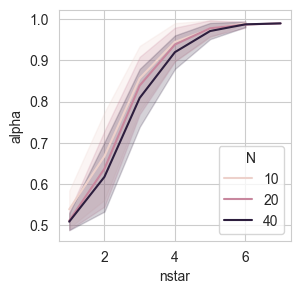

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(3, 3))

sns.lineplot(data=df_nstar, x="nstar", y="alpha", hue="N", ax=ax, errorbar="sd")
plt.show()

# Is $n^*$ any good?

Take the predicted $n^*$ and compute its reliability. Will it be above $\alpha$?

In [51]:
groupby_keys = ["na", "kernel", "N", "rep", "nstar"]

distr = du.UniformDistribution(na=8)
sample = distr.sample(2000)
kernel = Kernel.from_string(df_nstar["kernel"].values[0])
mmds = {}
for nstar in df_nstar["nstar"].unique():
    mmds[8, df_nstar["kernel"].values[0], nstar] = kernel.mmd_distribution(sample, n=nstar, rep=1000, disjoint=False, replace=True, method="vectorized")

# this alpha should be below the actual reliability for any n (including nstar)
def alphamin(ktildeP, eps, n):
    return 1 - 2 * (1 - ktildeP) / (eps**2 * n)

Kxx = kernel.gram_matrix(sample)
ktildeP = np.mean(Kxx - np.diag(np.diag(Kxx)))

out = []
for group, tmp in df_nstar.groupby(groupby_keys):
    na = group[0]
    kernel_name = group[1]
    N = group[2]
    rep = group[3]
    nstar = group[4]
    # maximum alpha associated to an nstar (i.e., predicted reliability for an nstar)
    alpha = tmp["alpha"].max()
    eps = tmp["eps"].values[0]

    # true reliability is obtained by sampling with replacement from a large enough pool
    out.append({
        "N": N,
        "rep": rep,
        "rel": np.mean(mmds[na, kernel_name, nstar] <= eps),
        "alpha": alpha,
        "nstar": nstar,
        "alphamin": alphamin(ktildeP, eps, nstar),
    })

    # print("EMMD^2_n - formula: ", np.mean(mmds[na, kernel_name, nstar] ** 2) - 2/nstar * (1-ktildeP))

dfrel = pd.DataFrame(out)



In [45]:
dfrel

,N,rep,rel,alpha,nstar,alphamin
0,10,0,0.000,0.49,1,-7.687585
1,10,0,0.000,0.79,2,-3.343793
2,10,0,0.000,0.93,3,-1.895862
3,10,0,0.012,0.99,4,-1.171896
4,10,1,0.000,0.55,1,-7.687585
...,...,...,...,...,...,...
604,40,48,0.063,0.99,5,-0.737517
605,40,49,0.000,0.77,2,-3.343793
606,40,49,0.000,0.91,3,-1.895862
607,40,49,0.012,0.97,4,-1.171896


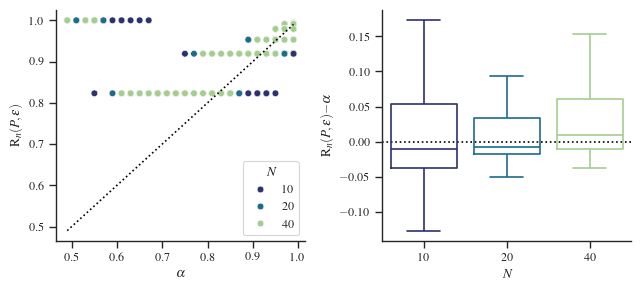

In [52]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import re
import seaborn as sns

mpl.rcParams['text.usetex'] = True                     # enable LaTeX
mpl.rcParams['text.latex.preamble'] = r"""
    \usepackage{mathptmx}
    \usepackage{amsmath}
    \usepackage{nicefrac}
"""
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif":  ["Times New Roman"],
})
sns.set(style="ticks", context="paper", font="serif")

boxplot_args = dict(
            showfliers=False,
            native_scale=False, fill=False, boxprops={"linewidth": 1.2},
        )

pretty_columns = dict(
    alpha=r"$\alpha$",
    rel=r"$\text{R}_n(P, \varepsilon)$",
    N=r"$N$",
)


dfplot = dfrel.copy()
dfplot.rename(columns=pretty_columns, inplace=True)

# dfplot = dfplot.drop(columns=["kernel"])

dfplot = dfplot.rename(columns=pretty_columns)

# We want to know if the alpha associated to nstar is greater than the actual reliability
# alpha means that we predict that nstar results are enough to achieve alpha reliability, so, the actual reliability at nstar should be above alpha
fig, axes = plt.subplots(1, 2, figsize=(6.5, 3))
axes = axes.flatten()

ax = axes[0]
sns.scatterplot(data = dfplot, x=dfplot[pretty_columns["alpha"]], y=dfplot[pretty_columns["rel"]], hue=pretty_columns["N"], ax=ax, palette="crest_r")
ax.plot(alphas, alphas, ls=":", c="black")

ax = axes[1]
dfplot[f"{pretty_columns["rel"]}$-${pretty_columns["alpha"]}"] = dfplot[pretty_columns["rel"]] - dfplot[pretty_columns["alpha"]]
ax.axhline(y=0, ls=":", c="black")
sns.boxplot(data=dfplot, x=pretty_columns["N"], y=f"{pretty_columns["rel"]}$-${pretty_columns["alpha"]}", ax=ax, **boxplot_args, hue=pretty_columns["N"], palette="crest_r", legend=False)


plt.tight_layout()
sns.despine(top=True, right=True)

plt.savefig(figures_dir / "rel_vs_alphanstar.pdf")